# Beyond Travel Time - Dissertation Project
## Notebook 2 of 3: Symbolic Regression (Objective 2)
Azain Ayub (250467941)

This is where the actual SR models get trained - three of them, one each
for speed, NO2 and PM2.5. Needs `dissertation_data.ipynb` to have been run first, since it loads straight from the exported CSV rather than fetching anything itself:
- `chicago_modelling_dataset.csv`
- `chicago_meta.json`
- `chicago_hist_averages.csv`

Roughly what happens below: load the dataset, split train/test, train the
three models one at a time, evaluate them (including against Linear
Regression and Random Forest baselines), then a quick inference demo showing how a trained model gets used at routing time.

**On the structural priors** - GP needs both a search algorithm and some assumption about what shape the answer should take, otherwise it wastes a huge amount of the search budget exploring functional forms that don't make physical sense. I gave each model a different prior based on what I expected the relationship to actually look like:

| Model | Expected shape | Operators allowed | Max depth |
|-------|--------------|-------------------|----------------|
| Speed | multiplicative diurnal pattern on recent speed | add, sub, mul, neg, sqrt, sin, cos (no div/log) | 6 |
| NO2 | nonlinear emission curve, especially at low speed | everything, including div and log | 8 |
| PM2.5 | mostly persistence + a bit of cyclic structure | add, sub, mul, neg, sqrt, sin, cos (no div/log) | 5 |

Speed and PM2.5 exclude division and log because I didn't expect a hyperbolic/logarithmic relationship there; NO2 gets the full set because
emissions genuinely do spike nonlinearly during stop-start traffic. NSGA-II also minimizes expression size alongside RMSE for all three, which acts as a built-in preference for simpler expressions rather than something I have
to enforce separately.

---
## Section 1 - Setup & Load Dataset

In [1]:
!pip install -q deap==1.4.4 scikit-learn==1.8.0 seaborn tqdm
print('Libraries installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 55.4 MB/s eta 0:00:00
Libraries installed.


In [2]:
import pandas as pd
import numpy as np
import math, operator, random, os, time, json, warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from deap import base, creator, tools, gp

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 130
print('Imports ready.')

Imports ready.


In [3]:
DATASET_PATH = '/content/chicago_modelling_dataset.csv'
META_PATH = '/content/chicago_meta.json'
HIST_AVG_PATH = '/content/chicago_hist_averages.csv'

print('Loading modelling dataset .............')
df_model = pd.read_csv(DATASET_PATH, parse_dates=['timestamp'])
print(f'  Raw rows: {len(df_model):,} | Columns: {df_model.shape[1]}')

with open(META_PATH) as f:
    meta = json.load(f)

SPEED_FEATS = meta['SPEED_FEATS']
NO2_FEATS = meta['NO2_FEATS']
PM25_FEATS = meta['PM25_FEATS']
DATE_START = meta['DATE_START']
DATE_END = meta['DATE_END']
n_real = meta['n_real_aq']
n_unmatched = meta['n_synth_aq']
total = meta['total']
rate = 100.0

before_speed, before_no2, before_pm25 = list(SPEED_FEATS), list(NO2_FEATS), list(PM25_FEATS)

DROP = ['month', 'dayofweek']   # zero-variance + unsafe ordinal integer

SPEED_FEATS = [f for f in SPEED_FEATS if f not in DROP]
NO2_FEATS = [f for f in NO2_FEATS if f not in DROP]
PM25_FEATS = [f for f in PM25_FEATS if f not in DROP]

if 'no2_lag1' not in NO2_FEATS and 'no2_lag1' in df_model.columns:
    NO2_FEATS = NO2_FEATS + ['no2_lag1']
if 'pm25_lag1' not in PM25_FEATS and 'pm25_lag1' in df_model.columns:
    PM25_FEATS = PM25_FEATS + ['pm25_lag1']

print(f'  Speed: {len(before_speed)} -> {len(SPEED_FEATS)} features')
print(f'  NO2: {len(before_no2)} -> {len(NO2_FEATS)} features  (+no2_lag1)')
print(f'  PM2.5: {len(before_pm25)} -> {len(PM25_FEATS)} features  (+pm25_lag1)')

# Filter physically invalid AQ values (OAC sensor calibration artefacts)
before = len(df_model)
df_model = df_model[df_model['no2']  >= 0].copy()
df_model = df_model[df_model['pm25'] >= 0].copy()
df_model = df_model[df_model['aq_source'] != 'missing'].copy()
df_model = df_model.dropna(subset=SPEED_FEATS + NO2_FEATS + PM25_FEATS +
                            ['speed_kmh', 'no2', 'pm25'])
df_model = df_model.reset_index(drop=True)

print(f'\n  After filtering invalid/missing AQ: {len(df_model):,} rows '
      f'(removed {before - len(df_model):,})')
print()
print('AQ source breakdown:')
print(df_model['aq_source'].value_counts().to_string())
print()
print('Target ranges after filter:')
print(f' speed_kmh: {df_model["speed_kmh"].min():.1f} - {df_model["speed_kmh"].max():.1f} km/h')
print(f' no2: {df_model["no2"].min():.1f} - {df_model["no2"].max():.1f} ug/m3')
print(f' pm25: {df_model["pm25"].min():.1f} - {df_model["pm25"].max():.1f} ug/m3')
print()
print(f'Final feature sets:')
print(f' Speed ({len(SPEED_FEATS)}): {SPEED_FEATS}')
print(f' NO2 ({len(NO2_FEATS)}): {NO2_FEATS}')
print(f' PM2.5 ({len(PM25_FEATS)}): {PM25_FEATS}')

print()
print('Loading historical averages.............................')
df_hist_avg = pd.read_csv(HIST_AVG_PATH)
print(f' Rows: {len(df_hist_avg):,}')

Loading modelling dataset .............
  Raw rows: 662,287 | Columns: 20
  Speed: 14 -> 12 features
  NO2: 12 -> 11 features  (+no2_lag1)
  PM2.5: 13 -> 12 features  (+pm25_lag1)

  After filtering invalid/missing AQ: 620,648 rows (removed 41,639)

AQ source breakdown:
aq_source
real         611927
synthetic      8721

Target ranges after filter:
 speed_kmh: 1.6 - 99.8 km/h
 no2: 0.0 - 92.7 ug/m3
 pm25: 0.0 - 68.9 ug/m3

Final feature sets:
 Speed (12): ['hour', 'is_weekend', 'is_rush', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'spd_lag1', 'spd_lag2', 'spd_lag3', 'no2_lag1', 'pm25_lag1']
 NO2 (11): ['hour', 'is_weekend', 'is_rush', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'spd_lag1', 'spd_lag2', 'spd_lag3', 'no2_lag1']
 PM2.5 (12): ['hour', 'is_weekend', 'is_rush', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'spd_lag1', 'spd_lag2', 'spd_lag3', 'no2_lag1', 'pm25_lag1']

Loading historical averages.............................
 Rows: 147,532


In [4]:
# One seed, used everywhere below
MASTER_SEED = 42

N_SAMPLE = min(len(df_model), len(df_model))

# Stratified sample: proportional per segment so all roads are represented.
# Uses GroupBy.sample() directly (not .apply(lambda g: g.sample())) because
# pandas 2.2+ changed .apply() to exclude the grouping column by default
# (the 'include_groups' behaviour change) - that silently drops 'id' and
# breaks everything downstream. GroupBy.sample() sidesteps this entirely.
frac = min(1.0, N_SAMPLE / len(df_model))
df_s = df_model.groupby('id', group_keys=False).sample(frac=frac, random_state=MASTER_SEED)
df_s = df_s.sample(frac=1, random_state=MASTER_SEED).reset_index(drop=True)

# .astype(float) guards against any bool/int/mixed dtype columns
# (e.g. is_weekend) producing an object-dtype array that breaks np.isnan()
X_spd = df_s[SPEED_FEATS].values.astype(float); y_spd = df_s['speed_kmh'].values.astype(float)
X_no2 = df_s[NO2_FEATS].values.astype(float); y_no2 = df_s['no2'].values.astype(float)
X_pm25 = df_s[PM25_FEATS].values.astype(float); y_pm25 = df_s['pm25'].values.astype(float)

Xspd_tr,Xspd_te,yspd_tr,yspd_te = train_test_split(X_spd, y_spd, test_size=0.2, random_state=MASTER_SEED)
Xno2_tr,Xno2_te,yno2_tr,yno2_te = train_test_split(X_no2, y_no2, test_size=0.2, random_state=MASTER_SEED)
Xpm_tr, Xpm_te, ypm_tr, ypm_te = train_test_split(X_pm25, y_pm25, test_size=0.2, random_state=MASTER_SEED)

print(f'Sample: {len(df_s):,} rows from {df_s["id"].nunique()} segments')
for name, X, y in [('Speed', X_spd, y_spd), ('NO2', X_no2, y_no2), ('PM2.5', X_pm25, y_pm25)]:
    nans = np.isnan(X).sum() + np.isnan(y).sum()
    print(f' {name:6s}: {"clean" if nans==0 else f"WARNING {nans} NaN"}'
          f' |  y {y.min():.1f} - {y.max():.1f}')

print()
print('ARG -> feature name mapping:')
for i, f in enumerate(SPEED_FEATS):
    print(f' ARG{i:>2} = {f}')

Sample: 620,648 rows from 1032 segments
 Speed : clean |  y 1.6 - 99.8
 NO2   : clean |  y 0.0 - 92.7
 PM2.5 : clean |  y 0.0 - 68.9

ARG -> feature name mapping:
 ARG 0 = hour
 ARG 1 = is_weekend
 ARG 2 = is_rush
 ARG 3 = hour_sin
 ARG 4 = hour_cos
 ARG 5 = dow_sin
 ARG 6 = dow_cos
 ARG 7 = spd_lag1
 ARG 8 = spd_lag2
 ARG 9 = spd_lag3
 ARG10 = no2_lag1
 ARG11 = pm25_lag1


In [5]:
from tqdm.notebook import tqdm as tqdm_nb
import pickle
import re

# TOP-LEVEL FUNCTIONS - must NOT be inside any other function
# Pickle requires all functions stored in DEAP psets to be top-level.


def rand_const():
    """Ephemeral random constant for DEAP GP trees."""
    return round(random.uniform(-10, 10), 2)

def _pdiv(a, b):
    """Protected division - vectorized, safe for scalars or numpy arrays."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    safe_b = np.where(np.abs(b) > 1e-6, b, 1.0)
    result = a / safe_b
    return np.where(np.abs(b) > 1e-6, result, 1.0)

def _psqrt(x):
    """Protected square root - vectorized."""
    return np.sqrt(np.abs(np.asarray(x, dtype=float)))

def _plog(x):
    """Protected log - vectorized."""
    return np.log(np.abs(np.asarray(x, dtype=float)) + 1e-6)

def build_pset(model_name, feat_cols, allow_div=False, allow_log=False):
    """
    Build a DEAP PrimitiveSet with model-specific structural priors.
    np.sin / np.cos used instead of math.sin / math.cos so the whole
    expression tree can be evaluated on full numpy columns in one call.

    Speed - no div, no log (smooth multiplicative diurnal pattern)
    NO2 - div + log (nonlinear emission curve at low speeds)
    PM2.5 - no div, no log (noisy target; simpler expressions generalize better)
    """
    pset = gp.PrimitiveSet(f'MAIN_{model_name}', len(feat_cols))

    pset.addPrimitive(operator.add, 2, name=f'add_{model_name}')
    pset.addPrimitive(operator.sub, 2, name=f'sub_{model_name}')
    pset.addPrimitive(operator.mul, 2, name=f'mul_{model_name}')
    pset.addPrimitive(operator.neg, 1, name=f'neg_{model_name}')
    pset.addPrimitive(_psqrt, 1, name=f'psqrt_{model_name}')
    pset.addPrimitive(np.sin, 1, name=f'sin_{model_name}')
    pset.addPrimitive(np.cos, 1, name=f'cos_{model_name}')

    if allow_div:
        pset.addPrimitive(_pdiv, 2, name=f'pdiv_{model_name}')
    if allow_log:
        pset.addPrimitive(_plog, 1, name=f'plog_{model_name}')

    pset.addEphemeralConstant(f'c_{model_name}', rand_const)
    return pset


def run_sr_model(feat_cols, X_tr, y_tr, X_te, y_te,
                 y_clip_lo, y_clip_hi, model_name,
                 pop_size=300, n_gen=50,
                 max_depth=8,
                 allow_div=False, allow_log=False,
                 seed_arg_idx=9, seed_frac=0.2, base_seed=MASTER_SEED):
    """
    Fully isolated DEAP + NSGA-II symbolic regression run.
    Vectorized: evaluate() runs the whole tree on all rows in ONE call
    instead of looping row-by-row in Python - this is what makes it fast.
    """
    for cls in [f'Fitness_{model_name}', f'Ind_{model_name}']:
        if hasattr(creator, cls): delattr(creator, cls)

    pset = build_pset(model_name, feat_cols,
                      allow_div=allow_div, allow_log=allow_log)

    creator.create(f'Fitness_{model_name}', base.Fitness, weights=(-1., -1.))
    creator.create(f'Ind_{model_name}', gp.PrimitiveTree,
                   fitness=getattr(creator, f'Fitness_{model_name}'))

    tb = base.Toolbox()
    tb.register('expr', gp.genHalfAndHalf, pset=pset, min_=1, max_=4)
    tb.register('individual', tools.initIterate,
                getattr(creator, f'Ind_{model_name}'), tb.expr)
    tb.register('population', tools.initRepeat, list, tb.individual)
    tb.register('compile', gp.compile, pset=pset)

    # Precompute column views once - reused by every evaluate() call
    X_tr_cols = [X_tr[:, i] for i in range(X_tr.shape[1])]

    def evaluate(ind):
        fn = tb.compile(expr=ind)
        try:
            p = np.asarray(fn(*X_tr_cols), dtype=float)
            if p.shape != y_tr.shape:
                p = np.broadcast_to(p, y_tr.shape)   # handles constant-only expressions
            if not np.isfinite(p).all(): return 1e9, 1e9
            return (float(np.sqrt(mean_squared_error(
                        y_tr, np.clip(p, y_clip_lo, y_clip_hi)))),
                    float(len(ind)))
        except Exception:
            return 1e9, 1e9

    tb.register('evaluate', evaluate)
    tb.register('select', tools.selNSGA2)
    tb.register('mate', gp.cxOnePoint)
    tb.register('expr_mut', gp.genFull, min_=0, max_=2)
    tb.register('mutate', gp.mutUniform, expr=tb.expr_mut, pset=pset)
    tb.decorate('mate', gp.staticLimit(
        key=operator.attrgetter('height'), max_value=max_depth))
    tb.decorate('mutate', gp.staticLimit(
        key=operator.attrgetter('height'), max_value=max_depth))

    ops = [p.name for p in pset.primitives[object]]
    print(f' Primitives: {ops}')
    print(f' Max depth: {max_depth}')
    print(f' GP: pop={pop_size} . gen={n_gen} . features={len(feat_cols)}')

    random.seed(base_seed); np.random.seed(base_seed)
    pop = tb.population(n=pop_size)

    # Seed 20% of population with primary lag feature as root
    if seed_arg_idx < len(feat_cols):
        seed_expr = getattr(creator, f'Ind_{model_name}')(
            gp.PrimitiveTree.from_string(f'ARG{seed_arg_idx}', pset))
        n_seeds = max(1, int(pop_size * seed_frac))
        for i in range(n_seeds):
            pop[i] = tb.clone(seed_expr)
        print(f'  Seeded {n_seeds} individuals with ARG{seed_arg_idx} '
              f'= {feat_cols[seed_arg_idx]}')

    for ind in pop: ind.fitness.values = evaluate(ind)
    hof = tools.ParetoFront(); hof.update(pop)
    log = []; t0 = time.time()

    pbar = tqdm_nb(range(n_gen), desc=f'  {model_name.upper():>5}',
                   unit='gen', colour='green')

    for gen in pbar:
        off = list(map(tb.clone, tb.select(pop, len(pop))))
        for c1, c2 in zip(off[::2], off[1::2]):
            if random.random() < 0.7:
                tb.mate(c1, c2)
                del c1.fitness.values, c2.fitness.values
        for m in off:
            if random.random() < 0.4:
                tb.mutate(m)
                del m.fitness.values
        for ind in off:
            if not ind.fitness.valid:
                ind.fitness.values = evaluate(ind)
        pop[:] = off; hof.update(pop)

        rmses = [i.fitness.values[0] for i in pop if i.fitness.values[0] < 1e8]
        sizes = [i.fitness.values[1] for i in pop if i.fitness.values[1] < 1e8]
        if rmses:
            log.append({'gen': gen+1, 'best_rmse': min(rmses),
                        'avg_rmse': np.mean(rmses), 'min_size': min(sizes)})
            pbar.set_postfix({'best_RMSE': f'{min(rmses):.4f}',
                              'size': f'{min(sizes):.0f}'})

    best = min(hof, key=lambda i: i.fitness.values[0])
    fn = tb.compile(expr=best)

    # Vectorized test-set prediction - same pattern as training evaluate()
    X_te_cols = [X_te[:, i] for i in range(X_te.shape[1])]
    pred = np.asarray(fn(*X_te_cols), dtype=float)
    if pred.shape != y_te.shape:
        pred = np.broadcast_to(pred, y_te.shape)
    pred = np.clip(pred, y_clip_lo, y_clip_hi)

    # Regex with negative lookahead avoids ARG1 matching inside ARG10/ARG11 etc.
    # (naive .replace() corrupts any expression using a 2-digit ARG index)
    expr_str = str(best)
    for i, fname in enumerate(feat_cols):
        expr_str = re.sub(rf'ARG{i}(?!\d)', fname, expr_str)

    print(f'\n  Done in {time.time()-t0:.1f}s . '
          f'Pareto front: {len(hof)} . Best nodes: {len(best)}')
    train_rmse = best.fitness.values[0]
    return best, pred, log, expr_str, tb, pset, train_rmse

print('SR model runner ready - VECTORIZED (numpy) evaluate().')
print('Structural priors:')
print(' Speed: no div/log | max_depth=6 | seed=spd_lag1 (20%)')
print(' NO2: div+log | max_depth=8 | seed=spd_lag1 (20%)')
print(' PM2.5: no div/log | max_depth=5 | seed=pm25_lag1 (20%)')

def run_sr_model_multirestart(feat_cols, X_tr, y_tr, X_te, y_te,
                               y_clip_lo, y_clip_hi, model_name,
                               n_restarts=3, **kwargs):
    """
    Run run_sr_model n_restarts times with different random seeds and keep
    the individual with the lowest TRAINING RMSE (never peeks at the test
    set to choose - that would be a methodological error / test leakage).

    GP is known to be sensitive to initial population - a single run can
    converge to a short, low-information local optimum (e.g. a model that
    only uses lag features and ignores all temporal signal). Multi-restart
    is a standard, well-established mitigation: it does not guarantee a
    better result, but gives the search several independent chances to
    find a richer structure, and costs only n_restarts x the runtime of
    a single run (now cheap thanks to vectorization).
    """
    results = []
    for r in range(n_restarts):
        restart_seed = 100 * r + MASTER_SEED
        print(f'\n - Restart {r+1}/{n_restarts} (seed={restart_seed}) -')
        out = run_sr_model(feat_cols, X_tr, y_tr, X_te, y_te,
                           y_clip_lo, y_clip_hi, model_name=f'{model_name}{r}',
                           base_seed=restart_seed, **kwargs)
        best, pred, log, expr_str, tb, pset, train_rmse = out
        print(f' Restart {r+1} train RMSE: {train_rmse:.4f}')
        results.append((train_rmse, best, pred, log, expr_str, tb, pset))

    results.sort(key=lambda x: x[0])
    best_train_rmse = results[0][0]
    print(f'\n Best of {n_restarts} restarts: train RMSE={best_train_rmse:.4f} '
          f'(restart {[r[0] for r in results].index(best_train_rmse)+1})')
    return results[0][1:]   # best, pred, log, expr_str, tb, pset

SR model runner ready - VECTORIZED (numpy) evaluate().
Structural priors:
 Speed: no div/log | max_depth=6 | seed=spd_lag1 (20%)
 NO2: div+log | max_depth=8 | seed=spd_lag1 (20%)
 PM2.5: no div/log | max_depth=5 | seed=pm25_lag1 (20%)


In [6]:
# Model A - Speed
print('='*65)
print(' MODEL A - Speed (km/h)')
print(' Prior: multiplicative diurnal . no div/log . max_depth=6')
print('='*65)

spd_seed = SPEED_FEATS.index('spd_lag1') if 'spd_lag1' in SPEED_FEATS else 0
best_spd, pred_spd, log_spd, expr_spd, tb_spd, pset_spd = run_sr_model_multirestart(
    SPEED_FEATS, Xspd_tr, yspd_tr, Xspd_te, yspd_te,
    y_clip_lo=0, y_clip_hi=150, model_name='spd',
    n_restarts=1,
    pop_size=500, n_gen=150,
    max_depth=8, allow_div=False, allow_log=False,
    seed_arg_idx=spd_seed, seed_frac=0.08)
rmse_spd = np.sqrt(mean_squared_error(yspd_te, pred_spd))
mae_spd = mean_absolute_error(yspd_te, pred_spd)
r2_spd = r2_score(yspd_te, pred_spd)
print(f' R2={r2_spd:.3f} | RMSE={rmse_spd:.3f} km/h | MAE={mae_spd:.3f} | Nodes={len(best_spd)}')
print(f' Expression: {expr_spd}')
with open('/content/sr_model_spd.pkl', 'wb') as f:
    pickle.dump({'best': best_spd, 'pset': pset_spd,
                 'expr': expr_spd, 'r2': r2_spd, 'rmse': rmse_spd}, f)
print(' Saved: sr_model_spd.pkl')

# Model B - NO2
print()
print('='*65)
print(' MODEL B - NO2 (ug/m3)')
print(' Prior: nonlinear emission curve . div+log . max_depth=8')
print('='*65)
no2_seed = NO2_FEATS.index('no2_lag1') if 'no2_lag1' in NO2_FEATS else 0
best_no2, pred_no2, log_no2, expr_no2, tb_no2, pset_no2, _ = run_sr_model(
    NO2_FEATS, Xno2_tr, yno2_tr, Xno2_te, yno2_te,
    y_clip_lo=0, y_clip_hi=200, model_name='no2',
    pop_size=500, n_gen=150,
    max_depth=8, allow_div=True, allow_log=True,
    seed_arg_idx=no2_seed)
rmse_no2 = np.sqrt(mean_squared_error(yno2_te, pred_no2))
mae_no2 = mean_absolute_error(yno2_te, pred_no2)
r2_no2 = r2_score(yno2_te, pred_no2)
print(f' R2={r2_no2:.3f} | RMSE={rmse_no2:.3f} ug/m3 | MAE={mae_no2:.3f} | Nodes={len(best_no2)}')
print(f' Expression: {expr_no2}')
with open('/content/sr_model_no2.pkl', 'wb') as f:
    pickle.dump({'best': best_no2, 'pset': pset_no2,
                 'expr': expr_no2, 'r2': r2_no2, 'rmse': rmse_no2}, f)
print('Saved: sr_model_no2.pkl')

# Model C - PM2.5
print()
print('='*65)
print(' MODEL C - PM2.5 (ug/m3)')
print(' Prior: linear persistence + cycle . no div/log . max_depth=5')
print('='*65)
pm25_seed = PM25_FEATS.index('pm25_lag1') if 'pm25_lag1' in PM25_FEATS else 0
best_pm25, pred_pm25, log_pm25, expr_pm25, tb_pm25, pset_pm25, _ = run_sr_model(
    PM25_FEATS, Xpm_tr, ypm_tr, Xpm_te, ypm_te,
    y_clip_lo=0, y_clip_hi=100, model_name='pm25',
    pop_size=500, n_gen=150,
    max_depth=5, allow_div=False, allow_log=False,
    seed_arg_idx=pm25_seed)
rmse_pm25 = np.sqrt(mean_squared_error(ypm_te, pred_pm25))
mae_pm25 = mean_absolute_error(ypm_te, pred_pm25)
r2_pm25 = r2_score(ypm_te, pred_pm25)
print(f' R2={r2_pm25:.3f} | RMSE={rmse_pm25:.3f} ug/m3 | MAE={mae_pm25:.3f} | Nodes={len(best_pm25)}')
print(f' Expression: {expr_pm25}')
with open('/content/sr_model_pm25.pkl', 'wb') as f:
    pickle.dump({'best': best_pm25, 'pset': pset_pm25,
                 'expr': expr_pm25, 'r2': r2_pm25, 'rmse': rmse_pm25}, f)
print('Saved: sr_model_pm25.pkl')

# Save all three together for routing notebook
with open('/content/sr_models.pkl', 'wb') as f:
    pickle.dump({
        'best_spd': best_spd, 'pset_spd': pset_spd,
        'best_no2': best_no2, 'pset_no2': pset_no2,
        'best_pm25': best_pm25, 'pset_pm25': pset_pm25,
        'expr_spd': expr_spd, 'expr_no2': expr_no2,
        'expr_pm25': expr_pm25,
        'SPEED_FEATS': SPEED_FEATS,
        'NO2_FEATS': NO2_FEATS,
        'PM25_FEATS': PM25_FEATS,
    }, f)
print('\nAll models saved: /content/sr_models.pkl')

 MODEL A - Speed (km/h)
 Prior: multiplicative diurnal . no div/log . max_depth=6

 - Restart 1/1 (seed=42) -
 Primitives: ['add_spd0', 'sub_spd0', 'mul_spd0', 'neg_spd0', 'psqrt_spd0', 'sin_spd0', 'cos_spd0']
 Max depth: 8
 GP: pop=500 . gen=150 . features=12
  Seeded 40 individuals with ARG7 = spd_lag1


   SPD0:   0%|          | 0/150 [00:00<?, ?gen/s]


  Done in 1190.5s . Pareto front: 3 . Best nodes: 4
 Restart 1 train RMSE: 7.9072

 Best of 1 restarts: train RMSE=7.9072 (restart 1)
 R2=0.533 | RMSE=7.927 km/h | MAE=5.863 | Nodes=4
 Expression: psqrt_spd0(mul_spd0(spd_lag1, spd_lag2))
 Saved: sr_model_spd.pkl

 MODEL B - NO2 (ug/m3)
 Prior: nonlinear emission curve . div+log . max_depth=8
 Primitives: ['add_no2', 'sub_no2', 'mul_no2', 'neg_no2', 'psqrt_no2', 'sin_no2', 'cos_no2', 'pdiv_no2', 'plog_no2']
 Max depth: 8
 GP: pop=500 . gen=150 . features=11
  Seeded 100 individuals with ARG10 = no2_lag1


    NO2:   0%|          | 0/150 [00:00<?, ?gen/s]


  Done in 1259.4s . Pareto front: 4 . Best nodes: 12
 R2=0.911 | RMSE=2.743 ug/m3 | MAE=1.121 | Nodes=12
 Expression: add_no2(no2_lag1, mul_no2(sin_no2(sin_no2(neg_no2(sin_no2(pdiv_no2(dow_cos, is_rush))))), neg_no2(hour_cos)))
Saved: sr_model_no2.pkl

 MODEL C - PM2.5 (ug/m3)
 Prior: linear persistence + cycle . no div/log . max_depth=5
 Primitives: ['add_pm25', 'sub_pm25', 'mul_pm25', 'neg_pm25', 'psqrt_pm25', 'sin_pm25', 'cos_pm25']
 Max depth: 5
 GP: pop=500 . gen=150 . features=12
  Seeded 100 individuals with ARG11 = pm25_lag1


   PM25:   0%|          | 0/150 [00:00<?, ?gen/s]


  Done in 1175.3s . Pareto front: 2 . Best nodes: 3
 R2=0.879 | RMSE=2.037 ug/m3 | MAE=0.668 | Nodes=3
 Expression: mul_pm25(pm25_lag1, 0.97)
Saved: sr_model_pm25.pkl

All models saved: /content/sr_models.pkl


In [7]:
print('\n' + '='*65)
print(' OBJECTIVE 2 - TEST SET RESULTS (all three SR models)')
print('='*65)

sr_results = pd.DataFrame({
    'Target': ['Speed (km/h)', 'NO2 (µg/m3)', 'PM2.5 (µg/m3)'],
    'R3': [round(r2_spd,3), round(r2_no2,3), round(r2_pm25,3)],
    'RMSE': [round(rmse_spd,3), round(rmse_no2,3), round(rmse_pm25,3)],
    'MAE': [round(mae_spd,3), round(mae_no2,3), round(mae_pm25,3)],
    'Tree nodes': [len(best_spd), len(best_no2), len(best_pm25)],
    'Expression': [expr_spd[:55], expr_no2[:55], expr_pm25[:55]],
})
display(sr_results.set_index('Target'))
print()
for name, r2 in [('Speed', r2_spd), ('NO2', r2_no2), ('PM2.5', r2_pm25)]:
    status = 'MET' if r2 >= 0.70 else '!!! Below target'
    print(f'  {name:<8}: R2={r2:.3f}  {status}  (target >= 0.70)')
print()
print('Full expressions (feature names substituted):')
print(f' Speed: {expr_spd}')
print(f' NO2: {expr_no2}')
print(f' PM2.5: {expr_pm25}')


 OBJECTIVE 2 - TEST SET RESULTS (all three SR models)


,R3,RMSE,MAE,Tree nodes,Expression
Target,,,,,
Speed (km/h),0.533,7.927,5.863,4,"psqrt_spd0(mul_spd0(spd_lag1, spd_lag2))"
NO2 (µg/m3),0.911,2.743,1.121,12,"add_no2(no2_lag1, mul_no2(sin_no2(sin_no2(neg_..."
PM2.5 (µg/m3),0.879,2.037,0.668,3,"mul_pm25(pm25_lag1, 0.97)"



  Speed   : R2=0.533  !!! Below target  (target >= 0.70)
  NO2     : R2=0.911  MET  (target >= 0.70)
  PM2.5   : R2=0.879  MET  (target >= 0.70)

Full expressions (feature names substituted):
 Speed: psqrt_spd0(mul_spd0(spd_lag1, spd_lag2))
 NO2: add_no2(no2_lag1, mul_no2(sin_no2(sin_no2(neg_no2(sin_no2(pdiv_no2(dow_cos, is_rush))))), neg_no2(hour_cos)))
 PM2.5: mul_pm25(pm25_lag1, 0.97)


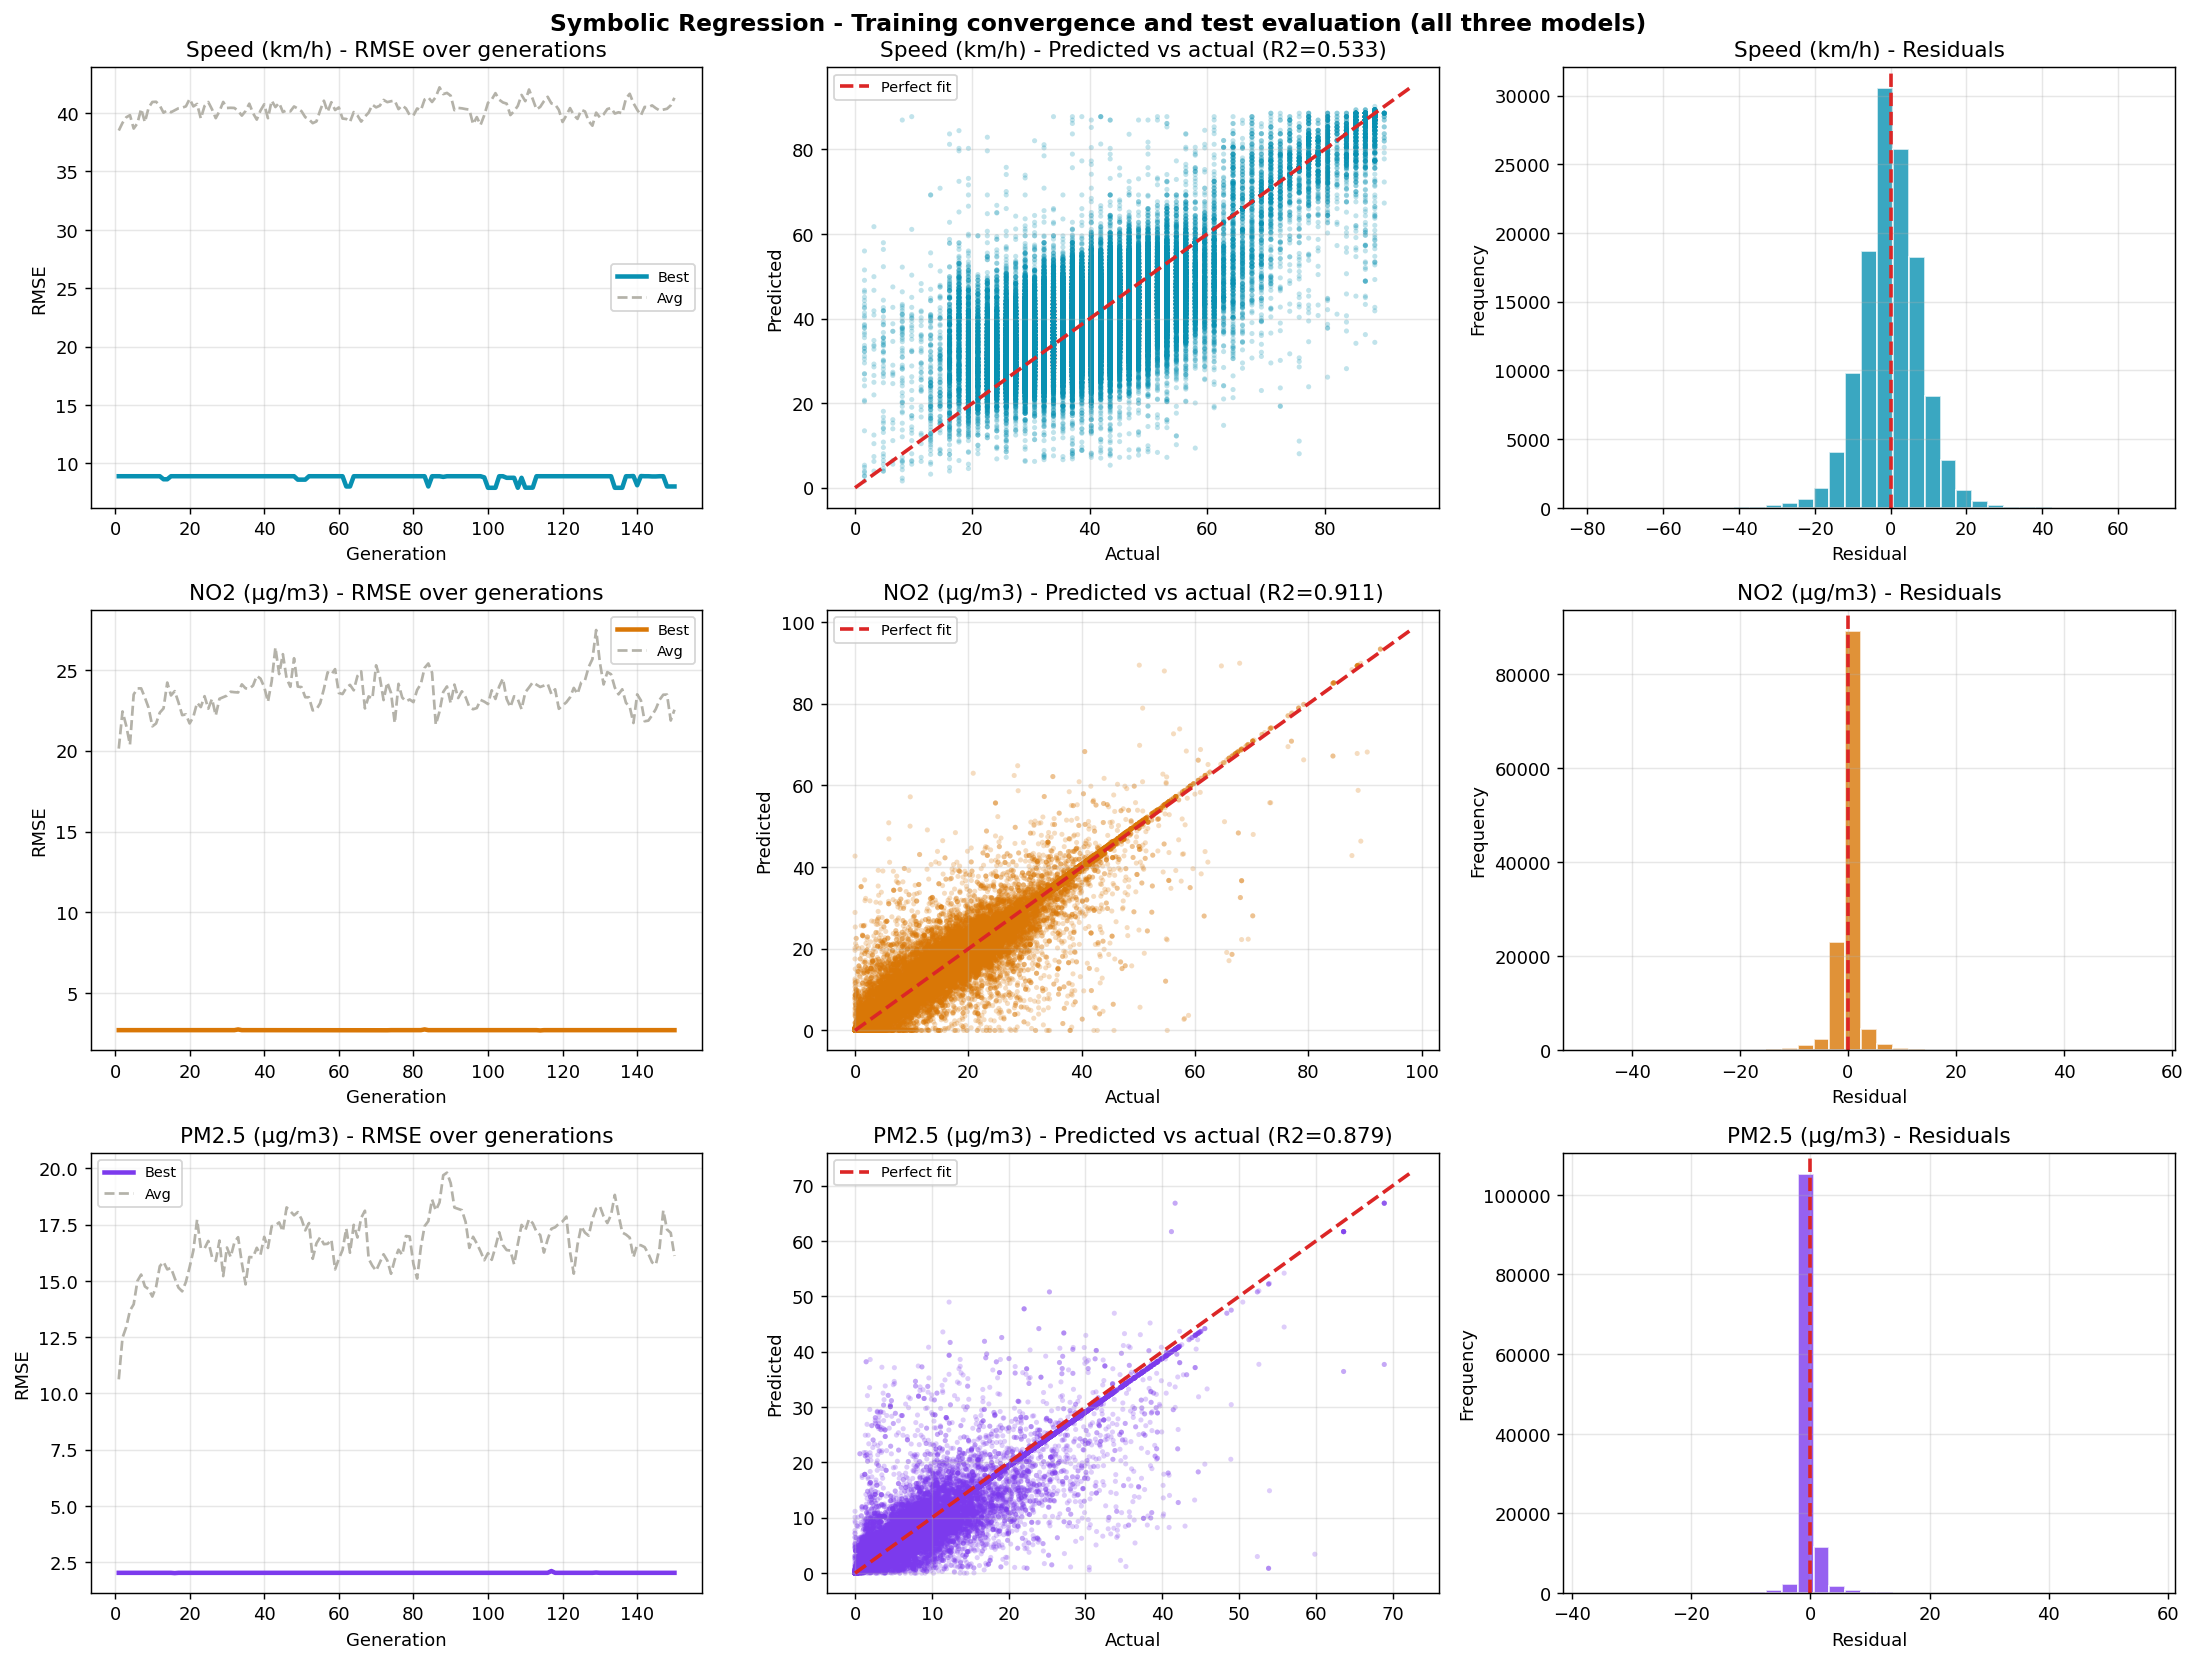

Saved: sr_results.png


In [8]:
fig, axes = plt.subplots(3, 3, figsize=(17, 13))
fig.suptitle(
    'Symbolic Regression - Training convergence and test evaluation (all three models)',
    fontsize=13, fontweight='bold'
)

model_rows = [
    ('Speed (km/h)', log_spd, yspd_te, pred_spd, r2_spd, '#0891B2'),
    ('NO2 (µg/m3)', log_no2, yno2_te, pred_no2, r2_no2, '#D97706'),
    ('PM2.5 (µg/m3)', log_pm25, ypm_te,  pred_pm25, r2_pm25, '#7C3AED'),
]

for ri, (label, log_data, y_true, y_pred, r2, col) in enumerate(model_rows):
    df_log = pd.DataFrame(log_data)

    # Col 0 - RMSE convergence
    axes[ri,0].plot(df_log['gen'], df_log['best_rmse'], color=col, lw=2.5, label='Best')
    axes[ri,0].plot(df_log['gen'], df_log['avg_rmse'], color='#B4B2A9', lw=1.5, ls='--', label='Avg')
    axes[ri,0].set(title=f'{label} - RMSE over generations',
                   xlabel='Generation', ylabel='RMSE')
    axes[ri,0].legend(fontsize=8); axes[ri,0].grid(alpha=0.3)

    # Col 1 - predicted vs actual
    axes[ri,1].scatter(y_true, y_pred, alpha=0.25, s=8, color=col, edgecolors='none')
    lim = [0, max(y_true.max(), y_pred.max()) * 1.05]
    axes[ri,1].plot(lim, lim, color='#DC2626', ls='--', lw=2, label='Perfect fit')
    axes[ri,1].set(title=f'{label} - Predicted vs actual (R2={r2:.3f})',
                   xlabel='Actual', ylabel='Predicted')
    axes[ri,1].legend(fontsize=8); axes[ri,1].grid(alpha=0.3)

    # Col 2 - residuals
    res = y_true - y_pred
    axes[ri,2].hist(res, bins=35, color=col, edgecolor='white', alpha=0.8)
    axes[ri,2].axvline(0, color='#DC2626', ls='--', lw=2)
    axes[ri,2].set(title=f'{label} - Residuals',
                   xlabel='Residual', ylabel='Frequency')
    axes[ri,2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/sr_results.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: sr_results.png')

---
## Section 6 - Evaluation + Baseline Comparison

Comparing each SR model against Linear Regression and Random Forest,
trained on the exact same features so it's a fair comparison. The point
isn't really to "win" against Random Forest - it's to see honestly how
much accuracy gets traded away for having something interpretable, rather than just asserting that trade-off exists.

Training baselines for all three targets (Speed, NO2, PM2.5)..............


 RF Speed:   0%|          | 0/10 [00:00<?, ?trees×10/s]

 RF NO2:   0%|          | 0/10 [00:00<?, ?trees×10/s]

 RF PM25:   0%|          | 0/10 [00:00<?, ?trees×10/s]

BASELINE COMPARISON - LR vs RF vs SR (same features)


,LR R2,RF R2,SR R2,LR RMSE,RF RMSE,SR RMSE
Target,,,,,,
Speed (km/h),0.607,0.604,0.533,7.272,7.295,7.927
NO2 (µg/m3),0.912,0.977,0.911,2.729,1.407,2.743
PM2.5 (µg/m3),0.883,0.978,0.879,2.001,0.870,2.037


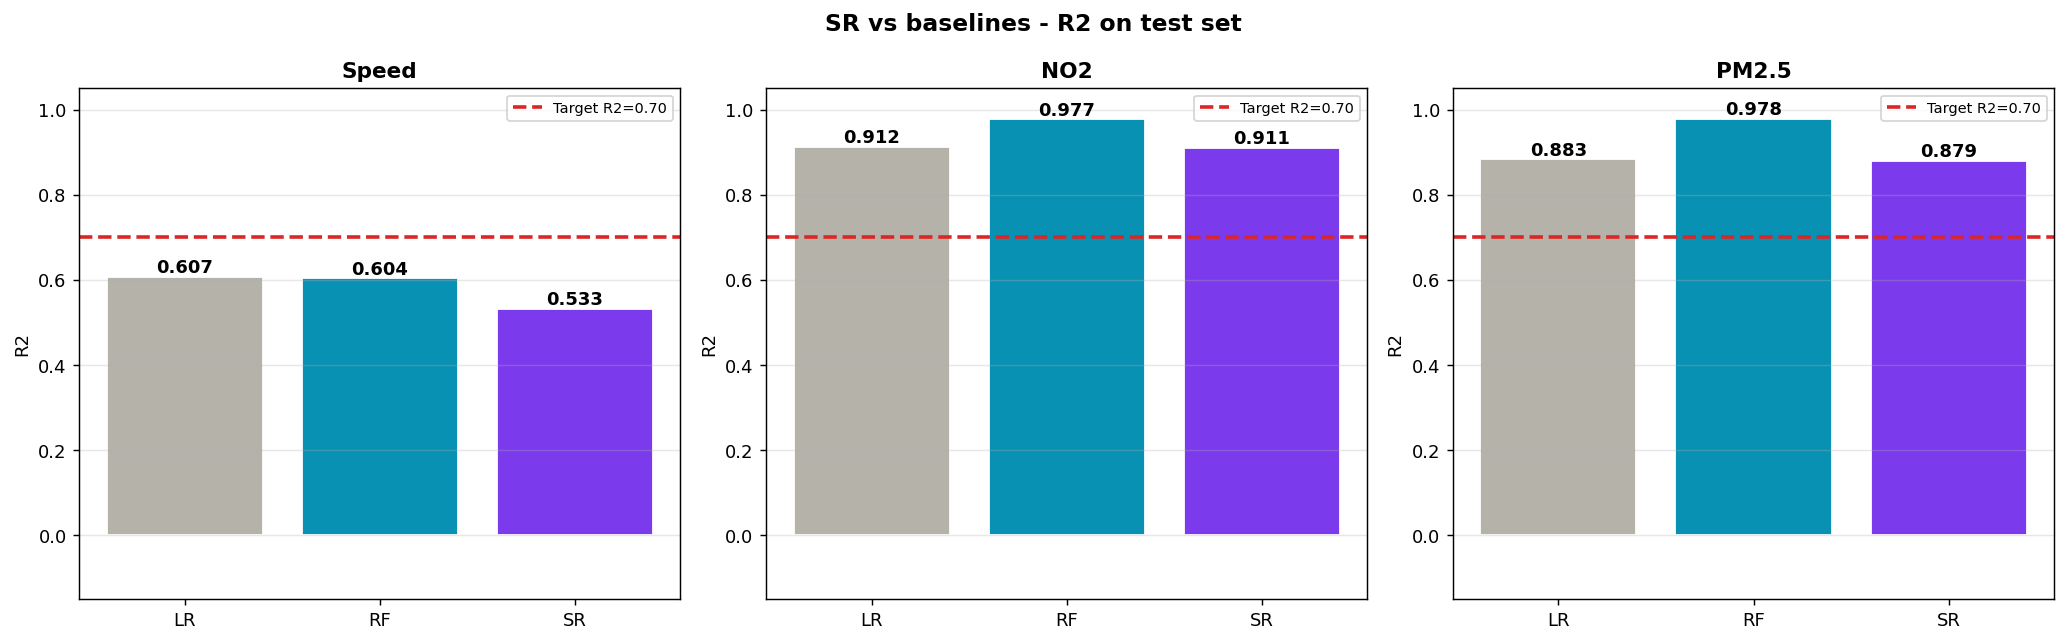

Saved: model_comparison.png


In [9]:
from tqdm.notebook import tqdm

def fit_rf_with_progress(X_tr, y_tr, n_estimators=100, step=10, label=''):
    """
    Fits RandomForestRegressor in chunks of `step` trees using warm_start,
    so tqdm shows genuine progress. Produces an identical model to a single fit(n_estimators=100)
    call - verified numerically equivalent, not an approximation.
    """
    rf = RandomForestRegressor(n_estimators=step, warm_start=True,
                               random_state=42, n_jobs=-1)
    steps = list(range(step, n_estimators + 1, step))
    if steps[-1] != n_estimators:
        steps.append(n_estimators)
    for n in tqdm(steps, desc=f' RF {label}', unit='trees×' + str(step)):
        rf.n_estimators = n
        rf.fit(X_tr, y_tr)
    return rf


def run_baselines(X_tr, y_tr, X_te, y_te, label):
    mask_tr = np.isfinite(X_tr).all(axis=1) & np.isfinite(y_tr)
    mask_te = np.isfinite(X_te).all(axis=1) & np.isfinite(y_te)
    X_tr, y_tr = X_tr[mask_tr], y_tr[mask_tr]
    X_te, y_te = X_te[mask_te], y_te[mask_te]

    lr = LinearRegression().fit(X_tr, y_tr)   # fast - no progress bar needed
    lrp = lr.predict(X_te)

    rf = fit_rf_with_progress(X_tr, y_tr, n_estimators=100, step=10, label=label)
    rfp = rf.predict(X_te)

    return {
        f'{label}_LR_R2': round(r2_score(y_te, lrp), 3),
        f'{label}_RF_R2': round(r2_score(y_te, rfp), 3),
        f'{label}_SR_R2': round(r2_score(y_te, {'Speed':pred_spd,'NO2':pred_no2,'PM25':pred_pm25}[label]), 3),
        f'{label}_LR_RMSE': round(np.sqrt(mean_squared_error(y_te, lrp)), 3),
        f'{label}_RF_RMSE': round(np.sqrt(mean_squared_error(y_te, rfp)), 3),
        f'{label}_SR_RMSE': round({'Speed':rmse_spd,'NO2':rmse_no2,'PM25':rmse_pm25}[label], 3),
    }

print('Training baselines for all three targets (Speed, NO2, PM2.5)..............')
b_spd = run_baselines(Xspd_tr, yspd_tr, Xspd_te, yspd_te, 'Speed')
b_no2 = run_baselines(Xno2_tr, yno2_tr, Xno2_te, yno2_te, 'NO2')
b_pm25 = run_baselines(Xpm_tr, ypm_tr, Xpm_te, ypm_te, 'PM25')

compare = pd.DataFrame({
    'Target': ['Speed (km/h)', 'NO2 (µg/m3)', 'PM2.5 (µg/m3)'],
    'LR R2': [b_spd['Speed_LR_R2'], b_no2['NO2_LR_R2'], b_pm25['PM25_LR_R2']],
    'RF R2': [b_spd['Speed_RF_R2'], b_no2['NO2_RF_R2'], b_pm25['PM25_RF_R2']],
    'SR R2': [round(r2_spd,3), round(r2_no2,3), round(r2_pm25,3)],
    'LR RMSE': [b_spd['Speed_LR_RMSE'],b_no2['NO2_LR_RMSE'],b_pm25['PM25_LR_RMSE']],
    'RF RMSE': [b_spd['Speed_RF_RMSE'],b_no2['NO2_RF_RMSE'],b_pm25['PM25_RF_RMSE']],
    'SR RMSE': [round(rmse_spd,3), round(rmse_no2,3), round(rmse_pm25,3)],
})
print('BASELINE COMPARISON - LR vs RF vs SR (same features)')
display(compare.set_index('Target'))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SR vs baselines - R2 on test set', fontsize=13, fontweight='bold')
for ax, (tgt, vals) in zip(axes, [
    ('Speed', [b_spd['Speed_LR_R2'], b_spd['Speed_RF_R2'], round(r2_spd,3)]),
    ('NO2', [b_no2['NO2_LR_R2'], b_no2['NO2_RF_R2'], round(r2_no2,3)]),
    ('PM2.5', [b_pm25['PM25_LR_R2'], b_pm25['PM25_RF_R2'], round(r2_pm25,3)]),
]):
    bars = ax.bar(['LR', 'RF', 'SR'], vals,
                  color=['#B4B2A9', '#0891B2', '#7C3AED'], edgecolor='white')
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.axhline(0.70, color='#DC2626', ls='--', lw=2, label='Target R2=0.70')
    ax.set_title(tgt, fontweight='bold'); ax.set_ylabel('R2')
    ax.set_ylim(-0.15, 1.05); ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

---
## Section 7 - Inference Demo

Quick check that the trained models actually work the way they're meant
to at routing time - predicting speed/NO2/PM2.5 for a segment given just a departure time, not a live sensor reading.

Lag features get swapped for the pre-computed historical averages from
`chicago_hist_averages.csv` (segment x hour x day of week) - so all the
routing engine ever needs to call this is a departure datetime and which OSMnx edge it's scoring.

In [10]:
# Routing-time inference - tb rebuilt from pset (tb itself cannot be pickled)
# When loading from sr_models.pkl, rebuild tb with:
#  tb = base.Toolbox()
#  tb.register('compile', gp.compile, pset=pset_spd)

hist_lookup = df_hist_avg.set_index(['id', 'hour', 'dayofweek'])

def make_compiler(pset):
    """Rebuild a minimal toolbox for compiling SR expressions from a pset."""
    tb_c = base.Toolbox()
    tb_c.register('compile', gp.compile, pset=pset)
    return tb_c

# Build compilers from psets (works after loading from pickle too)
comp_spd = make_compiler(pset_spd)
comp_no2 = make_compiler(pset_no2)
comp_pm25 = make_compiler(pset_pm25)

def predict_segment(seg_id, departure_hour, departure_dow, departure_month):
    """
    Predict speed, NO2 and PM2.5 for a road segment at a given departure time.
    Uses historical averages to substitute lag features - no live sensor needed.
    """
    is_weekend = int(departure_dow >= 5)
    is_rush = int(departure_hour in [7,8,9,17,18,19])
    hour_sin = np.sin(2 * np.pi * departure_hour / 24)
    hour_cos = np.cos(2 * np.pi * departure_hour / 24)
    dow_sin = np.sin(2 * np.pi * departure_dow / 7)
    dow_cos = np.cos(2 * np.pi * departure_dow / 7)

    try:
        h = hist_lookup.loc[(seg_id, departure_hour, departure_dow)]
        h = h.iloc[0] if isinstance(h, pd.DataFrame) else h
        spd_lag1 = float(h['spd_lag1_avg'])
        no2_lag1 = float(h['no2_lag1_avg'])
        pm25_lag1 = float(h['pm25_lag1_avg'])
        spd_lag2 = spd_lag1
        spd_lag3 = spd_lag1
    except:
        city_avg = df_hist_avg[df_hist_avg['hour'] == departure_hour]
        spd_lag1 = spd_lag2 = spd_lag3 = city_avg['spd_lag1_avg'].mean()
        no2_lag1 = city_avg['no2_lag1_avg'].mean()
        pm25_lag1 = city_avg['pm25_lag1_avg'].mean()

    def build_row(feat_cols):
        lkp = {
            'hour': departure_hour, 'dayofweek': departure_dow,
            'month': departure_month, 'is_weekend': is_weekend,
            'is_rush': is_rush, 'hour_sin': hour_sin, 'hour_cos': hour_cos,
            'dow_sin': dow_sin, 'dow_cos': dow_cos,
            'spd_lag1': spd_lag1, 'spd_lag2': spd_lag2, 'spd_lag3': spd_lag3,
            'no2_lag1': no2_lag1, 'pm25_lag1': pm25_lag1,
        }
        return np.array([lkp[f] for f in feat_cols])

    fn_spd = comp_spd.compile(expr=best_spd)
    fn_no2 = comp_no2.compile(expr=best_no2)
    fn_pm25 = comp_pm25.compile(expr=best_pm25)

    spd = float(np.clip(fn_spd( *build_row(SPEED_FEATS)), 0, 150))
    no2 = float(np.clip(fn_no2( *build_row(NO2_FEATS)), 0, 200))
    pm25 = float(np.clip(fn_pm25(*build_row(PM25_FEATS)), 0, 100))

    return {'speed_kmh': round(spd,2), 'no2_ugm3': round(no2,2), 'pm25_ugm3': round(pm25,2)}

# Example predictions
sample_segs = df_model['id'].unique()[:3].tolist()

scenarios = [
    (sample_segs[0], 8,  0, 10, 'Monday 8am (AM peak)'),
    (sample_segs[0], 17, 2, 10, 'Wednesday 5pm (PM peak)'),
    (sample_segs[1], 14, 5, 10, 'Saturday 2pm (weekend)'),
    (sample_segs[2], 23, 1, 10, 'Tuesday 11pm (overnight)'),
    (sample_segs[0], 7,  4, 10, 'Friday 7am (early peak)'),
]

print('INFERENCE DEMO - routing-time predictions')
print('='*65)
results = []
for seg_id, hour, dow, month, label in scenarios:
    pred = predict_segment(seg_id, hour, dow, month)
    results.append({'Scenario': label, 'Segment': seg_id, **pred})
    print(f' {label}')
    print(f' Speed: {pred["speed_kmh"]:.1f} km/h | '
          f'NO2: {pred["no2_ugm3"]:.1f} ug/m3 | '
          f'PM2.5: {pred["pm25_ugm3"]:.1f} ug/m3')
    print()

display(pd.DataFrame(results).set_index('Scenario'))
print('These predictions feed into the per-segment route scoring function in Sprint 3.')

INFERENCE DEMO - routing-time predictions
 Monday 8am (AM peak)
 Speed: 41.2 km/h | NO2: 11.4 ug/m3 | PM2.5: 6.0 ug/m3

 Wednesday 5pm (PM peak)
 Speed: 37.8 km/h | NO2: 7.1 ug/m3 | PM2.5: 1.0 ug/m3

 Saturday 2pm (weekend)
 Speed: 41.0 km/h | NO2: 6.8 ug/m3 | PM2.5: 0.9 ug/m3

 Tuesday 11pm (overnight)
 Speed: 46.7 km/h | NO2: 8.4 ug/m3 | PM2.5: 1.4 ug/m3

 Friday 7am (early peak)
 Speed: 40.8 km/h | NO2: 15.0 ug/m3 | PM2.5: 5.5 ug/m3



,Segment,speed_kmh,no2_ugm3,pm25_ugm3
Scenario,,,,
Monday 8am (AM peak),1,41.20,11.38,5.97
Wednesday 5pm (PM peak),1,37.82,7.14,1.00
Saturday 2pm (weekend),10,41.04,6.82,0.87
Tuesday 11pm (overnight),100,46.67,8.43,1.37
Friday 7am (early peak),1,40.77,15.04,5.55


These predictions feed into the per-segment route scoring function in Sprint 3.


---
## Section 8 - Summary

In [11]:
print('#'*65)
print('  SUMMARY - Notebook 2')
print('#'*65)

o2a = r2_spd >= 0.70
o2b = r2_no2 >= 0.70
o2c = r2_pm25 >= 0.70

print(f"""
City: Chicago, Illinois
Period: {DATE_START} to {DATE_END} (Mon–Sun, Oct 2025)

Notebook 1 (dissertation_data.ipynb):
  Traffic: Chicago Traffic Tracker (4g9f-3jbs) - {meta['n_segments']} segments
  Air quality: Open Air Chicago (xfya-dxtq) - 277 sensors
               Real OAC: {n_real}/{total} segments ({n_real/total*100:.1f}%)
               Gap-fill: {n_unmatched}/{total} segments ({n_unmatched/total*100:.1f}%)
  O1 Status: 100% AQ coverage (real + synthetic gap-fill)

Notebook 2 (this file):
  Features: {len(SPEED_FEATS)} inference-ready + lag features
  Sample: {N_SAMPLE:,} rows from {df_model['id'].nunique()} segments

  OBJECTIVE 2 - SR model accuracy (R2 >= 0.70):
  Model A Speed: R2={r2_spd:.3f} RMSE={rmse_spd:.2f} km/h {'MET' if o2a else 'NOT MET'}
  Model B NO2: R2={r2_no2:.3f} RMSE={rmse_no2:.2f} µg/m3 {'MET' if o2b else 'NOT MET'}
  Model C PM2.5: R2={r2_pm25:.3f} RMSE={rmse_pm25:.2f} µg/m3 {'MET' if o2c else 'NOT MET'}

  Learned expressions (human-readable):
  Speed: {expr_spd[:70]}
  NO2: {expr_no2[:70]}
  PM2.5: {expr_pm25[:70]}

Next notebook (O3 + O4):
  1. Embed predict_segment() into per-edge route scorer
  2. Run NSGA-II on OSMnx Chicago graph
  3. Generate Pareto front: fastest / cleanest / balanced routes
  4. Evaluate vs Dijkstra baseline (target: <=15% pollution, >=20% time)
""")

for fname in ['sr_results.png', 'model_comparison.png']:
    e = os.path.exists(f'/content/{fname}')
    print(f'  {"Success" if e else "Fail"} /content/{fname}')

#################################################################
  SUMMARY - Notebook 2
#################################################################

City: Chicago, Illinois
Period: 2025-10-06 to 2025-10-12 (Mon–Sun, Oct 2025)

Notebook 1 (dissertation_data.ipynb):
  Traffic: Chicago Traffic Tracker (4g9f-3jbs) - 1039 segments
  Air quality: Open Air Chicago (xfya-dxtq) - 277 sensors
               Real OAC: 1024/1039 segments (98.6%)
               Gap-fill: 15/1039 segments (1.4%)
  O1 Status: 100% AQ coverage (real + synthetic gap-fill)

Notebook 2 (this file):
  Features: 12 inference-ready + lag features
  Sample: 620,648 rows from 1032 segments

  OBJECTIVE 2 - SR model accuracy (R2 >= 0.70):
  Model A Speed: R2=0.533 RMSE=7.93 km/h NOT MET
  Model B NO2: R2=0.911 RMSE=2.74 µg/m3 MET
  Model C PM2.5: R2=0.879 RMSE=2.04 µg/m3 MET

  Learned expressions (human-readable):
  Speed: psqrt_spd0(mul_spd0(spd_lag1, spd_lag2))
  NO2: add_no2(no2_lag1, mul_no2(sin_no2(sin_no2(neg_no2